# 04 - MLP Baseline
Prosty MLP klasyfikujący węzły tylko na podstawie ich cech - bez informacji o strukturze grafu

In [1]:
import os, json
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from torch_geometric.datasets import Planetoid

os.makedirs('../models', exist_ok=True)
os.makedirs('../results', exist_ok=True)

dataset = Planetoid(root='../data/Cora', name='Cora')
data = dataset[0]
original_train_mask = data.train_mask.clone()

print(f'Węzły:    {data.num_nodes}')
print(f'Cechy:    {data.num_node_features}')
print(f'Klasy:    {dataset.num_classes}')

Węzły:    2708
Cechy:    1433
Klasy:    7


## Wczytanie wyników GCN, GAT, GraphSAGE

In [2]:
with open('../models/all_results.json') as f:
    all_raw = json.load(f)

all_results = {
    name: {float(k): v for k, v in res.items()}
    for name, res in all_raw.items()
}

ratios = [0.05, 0.10, 0.20]
seeds  = [42, 123, 456, 789, 1000]
labels = ['5%', '10%', '20%']

print('Wyniki wczytane:')
print(f'{"Model":<12} {"5%":>14} {"10%":>14} {"20%":>14}')
print('-' * 58)
for name, res in all_results.items():
    row = f'{name:<12}'
    for ratio in ratios:
        row += f'  {np.mean(res[ratio]):.4f}±{np.std(res[ratio]):.4f}'
    print(row)

Wyniki wczytane:
Model                    5%            10%            20%
----------------------------------------------------------
GCN           0.7922±0.0147  0.8152±0.0143  0.8274±0.0147
GAT           0.8058±0.0090  0.8208±0.0087  0.8448±0.0102
GraphSAGE     0.7952±0.0118  0.8218±0.0105  0.8424±0.0156


## Funkcje pomocnicze

In [3]:
def create_split(data, label_ratio, seed=42):
    torch.manual_seed(seed)

    available_indices = (~data.test_mask).nonzero(as_tuple=True)[0]

    train_size = int(data.num_nodes * label_ratio)
    shuffled = available_indices[torch.randperm(len(available_indices))]

    train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    train_mask[shuffled[:train_size]] = True

    return train_mask

def train(model, optimizer):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def test(model):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    acc = (pred[data.test_mask] == data.y[data.test_mask]).float().mean()
    return acc.item()

## Architektura MLP
MLP ignoruje strukturę grafu - klasyfikuje węzeł tylko na podstawie jego własnych cech
edge_index przyjmowany w forward() dla spójności API ale nie jest używany
Pokazuje ile informacji pochodzi z samego tekstu a ile z relacji cytowań

In [4]:
class MLP(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.fc1 = torch.nn.Linear(in_channels, hidden_channels)
        self.fc2 = torch.nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index=None):  # edge_index ignorowany
        x = self.fc1(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

## Baseline - standardowy split

In [5]:
data.train_mask = original_train_mask

baseline_model = MLP(dataset.num_features, 64, dataset.num_classes)
baseline_optimizer = torch.optim.Adam(
    baseline_model.parameters(), lr=0.01, weight_decay=5e-4)

for epoch in range(200):
    loss = train(baseline_model, baseline_optimizer)
    if epoch % 20 == 0:
        acc = test(baseline_model)
        print(f'Epoch {epoch:3d}: Loss={loss:.4f}, Acc={acc:.4f}')

baseline_acc = test(baseline_model)
print(f'\nBaseline MLP (paper split):  {baseline_acc:.4f}')
print(f'Dla porównania GCN baseline: 0.815')
print(f'Różnica (ile wnosi graf): {0.815 - baseline_acc:+.4f}')

Epoch   0: Loss=1.9481, Acc=0.2560
Epoch  20: Loss=0.0309, Acc=0.5540
Epoch  40: Loss=0.0062, Acc=0.5640
Epoch  60: Loss=0.0132, Acc=0.5680
Epoch  80: Loss=0.0107, Acc=0.5780
Epoch 100: Loss=0.0104, Acc=0.5730
Epoch 120: Loss=0.0081, Acc=0.5860
Epoch 140: Loss=0.0089, Acc=0.5910
Epoch 160: Loss=0.0101, Acc=0.5880
Epoch 180: Loss=0.0066, Acc=0.5860

Baseline MLP (paper split):  0.5750
Dla porównania GCN baseline: 0.815
Różnica (ile wnosi graf): +0.2400


## Eksperymenty - accuracy vs liczba etykiet

In [6]:
mlp_results = defaultdict(list)
best_acc = 0

for ratio in ratios:
    for seed in seeds:
        data.train_mask = create_split(data, ratio, seed)

        model = MLP(dataset.num_features, 64, dataset.num_classes)
        optimizer = torch.optim.Adam(
            model.parameters(), lr=0.01, weight_decay=5e-4)

        for epoch in range(200):
            train(model, optimizer)

        acc = test(model)
        mlp_results[ratio].append(acc)
        print(f'MLP | Ratio: {ratio:.0%}, Seed: {seed}, Acc: {acc:.4f}')

        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), '../models/mlp_best.pt')

data.train_mask = original_train_mask

print('\n--- Podsumowanie MLP ---')
for ratio, accs in mlp_results.items():
    print(f'{ratio:.0%}: {np.mean(accs):.4f} ± {np.std(accs):.4f}')
print(f'Najlepszy model: {best_acc:.4f}')

MLP | Ratio: 5%, Seed: 42, Acc: 0.5310
MLP | Ratio: 5%, Seed: 123, Acc: 0.5970
MLP | Ratio: 5%, Seed: 456, Acc: 0.5770
MLP | Ratio: 5%, Seed: 789, Acc: 0.5730
MLP | Ratio: 5%, Seed: 1000, Acc: 0.5830
MLP | Ratio: 10%, Seed: 42, Acc: 0.6440
MLP | Ratio: 10%, Seed: 123, Acc: 0.6330
MLP | Ratio: 10%, Seed: 456, Acc: 0.6320
MLP | Ratio: 10%, Seed: 789, Acc: 0.6050
MLP | Ratio: 10%, Seed: 1000, Acc: 0.6190
MLP | Ratio: 20%, Seed: 42, Acc: 0.7080
MLP | Ratio: 20%, Seed: 123, Acc: 0.7030
MLP | Ratio: 20%, Seed: 456, Acc: 0.6920
MLP | Ratio: 20%, Seed: 789, Acc: 0.6710
MLP | Ratio: 20%, Seed: 1000, Acc: 0.7050

--- Podsumowanie MLP ---
5%: 0.5722 ± 0.0221
10%: 0.6266 ± 0.0134
20%: 0.6958 ± 0.0135
Najlepszy model: 0.7080


## Ile wnosi struktura grafu
porównanie: różnica accuracy między GNN a MLP = wartość informacji z cytowań

In [7]:
all_results['MLP'] = dict(mlp_results)

print('--- Przewaga GNN nad MLP ---')
print(f'{"Model":<12} {"5%":>10} {"10%":>10} {"20%":>10}')
print('-' * 45)
for name in ['GCN', 'GAT', 'GraphSAGE']:
    row = f'{name:<12}'
    for ratio in ratios:
        diff = np.mean(all_results[name][ratio]) - np.mean(mlp_results[ratio])
        sign = '+' if diff >= 0 else ''
        row += f'  {sign}{diff:.4f}   '
    print(row)

--- Przewaga GNN nad MLP ---
Model                5%        10%        20%
---------------------------------------------
GCN           +0.2200     +0.1886     +0.1316   
GAT           +0.2336     +0.1942     +0.1490   
GraphSAGE     +0.2230     +0.1952     +0.1466   


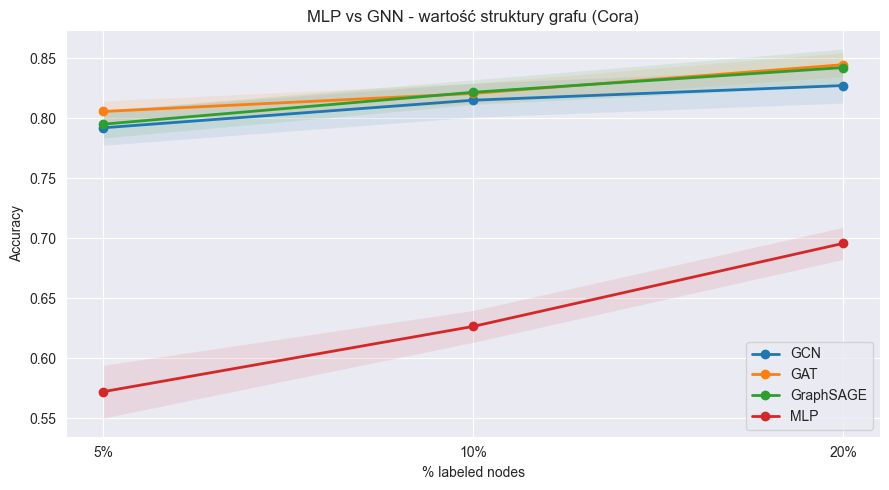

Wykres zapisany: ../results/mlp_vs_gnn.png


In [8]:
plt.figure(figsize=(9, 5))
for name, res in all_results.items():
    means = [np.mean(res[r]) for r in ratios]
    stds  = [np.std(res[r])  for r in ratios]
    plt.plot(labels, means,
             marker='o',
             linewidth=2, label=name)
    plt.fill_between(labels,
                     [m - s for m, s in zip(means, stds)],
                     [m + s for m, s in zip(means, stds)],
                     alpha=0.1)

plt.xlabel('% labeled nodes')
plt.ylabel('Accuracy')
plt.title('MLP vs GNN - wartość struktury grafu (Cora)')
plt.legend()
plt.tight_layout()
plt.savefig('../results/mlp_vs_gnn.png')
plt.show()
print('Wykres zapisany: ../results/mlp_vs_gnn.png')

In [ ]:
with open('../models/mlp_results.json', 'w') as f:
    json.dump({str(k): v for k, v in mlp_results.items()}, f, indent=2)

all_serializable = {
    name: {str(k): v for k, v in res.items()}
    for name, res in all_results.items()
}
with open('../models/all_results.json', 'w') as f:
    json.dump(all_serializable, f, indent=2)

print('Zapisano:')
print('../models/mlp_results.json')
print('../models/mlp_best.pt')
print('../models/all_results.json  (zaktualizowany o MLP)')
print('../results/mlp_vs_gnn.png')